# S&P 500 Empirical Study: Distribution Comparison

This notebook compares probability distributions for modeling S&P 500 daily log returns:

1. **Normal** — Gaussian baseline
2. **Student-t** — heavy tails, no skewness
3. **Variance Gamma (VG)** — Normal-Gamma mixture, semi-heavy tails
4. **Normal Inverse Gamma (NInvG)** — Normal-InverseGamma mixture
5. **Normal Inverse Gaussian (NIG)** — Normal-InverseGaussian mixture
6. **Generalized Hyperbolic (GH)** — most general normal variance-mean mixture
7. **Stable (Lévy)** — infinite variance reference

Methodology: 10 years of S&P 500 daily returns split into training/testing halves.
Normix distributions are fitted via EM; scipy distributions via MLE.
Evaluation includes PDF overlay, QQ plots, KS/AD tests, tail analysis, and VaR backtesting.

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import ks_2samp, anderson_ksamp
import warnings
warnings.filterwarnings('ignore')

from normix import (
    VarianceGamma, NormalInverseGamma, NormalInverseGaussian, GeneralizedHyperbolic,
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Imports successful!")

Imports successful!


## 1. Download and Prepare S&P 500 Data

In [3]:
import yfinance as yf
from datetime import datetime, timedelta

end_date = datetime.now()
start_date = end_date - timedelta(days=365*10 + 30)

print(f"Downloading S&P 500 data from {start_date.date()} to {end_date.date()}...")
sp500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)

print(f"Downloaded {len(sp500)} trading days")
print(f"Date range: {sp500.index[0].date()} to {sp500.index[-1].date()}")

Downloaded 2533 trading days
Date range: 2016-02-24 to 2026-03-20


In [4]:
sp500['Log_Return'] = np.log(sp500['Close'] / sp500['Close'].shift(1))
sp500 = sp500.dropna()

n_total = len(sp500)
n_train = n_total // 2

train_data = sp500.iloc[:n_train]
test_data = sp500.iloc[n_train:]

returns_train = train_data['Log_Return'].values
returns_test = test_data['Log_Return'].values

print(f"\nTraining period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Training samples: {len(returns_train)}")
print(f"\nTesting period: {test_data.index[0].date()} to {test_data.index[-1].date()}")
print(f"Testing samples: {len(returns_test)}")

print(f"\n--- Training Data Statistics ---")
print(f"Mean: {returns_train.mean()*100:.4f}%")
print(f"Std:  {returns_train.std()*100:.4f}%")
print(f"Skewness: {stats.skew(returns_train):.4f}")
print(f"Kurtosis: {stats.kurtosis(returns_train):.4f} (excess)")
print(f"Min:  {returns_train.min()*100:.4f}%")
print(f"Max:  {returns_train.max()*100:.4f}%")


Training period: 2016-02-25 to 2021-03-05
Training samples: 1266

Testing period: 2021-03-08 to 2026-03-20
Testing samples: 1266

--- Training Data Statistics ---
Mean: 0.0544%
Std:  1.2082%
Skewness: -1.1631
Kurtosis: 22.6041 (excess)
Min:  -12.7652%
Max:  8.9683%


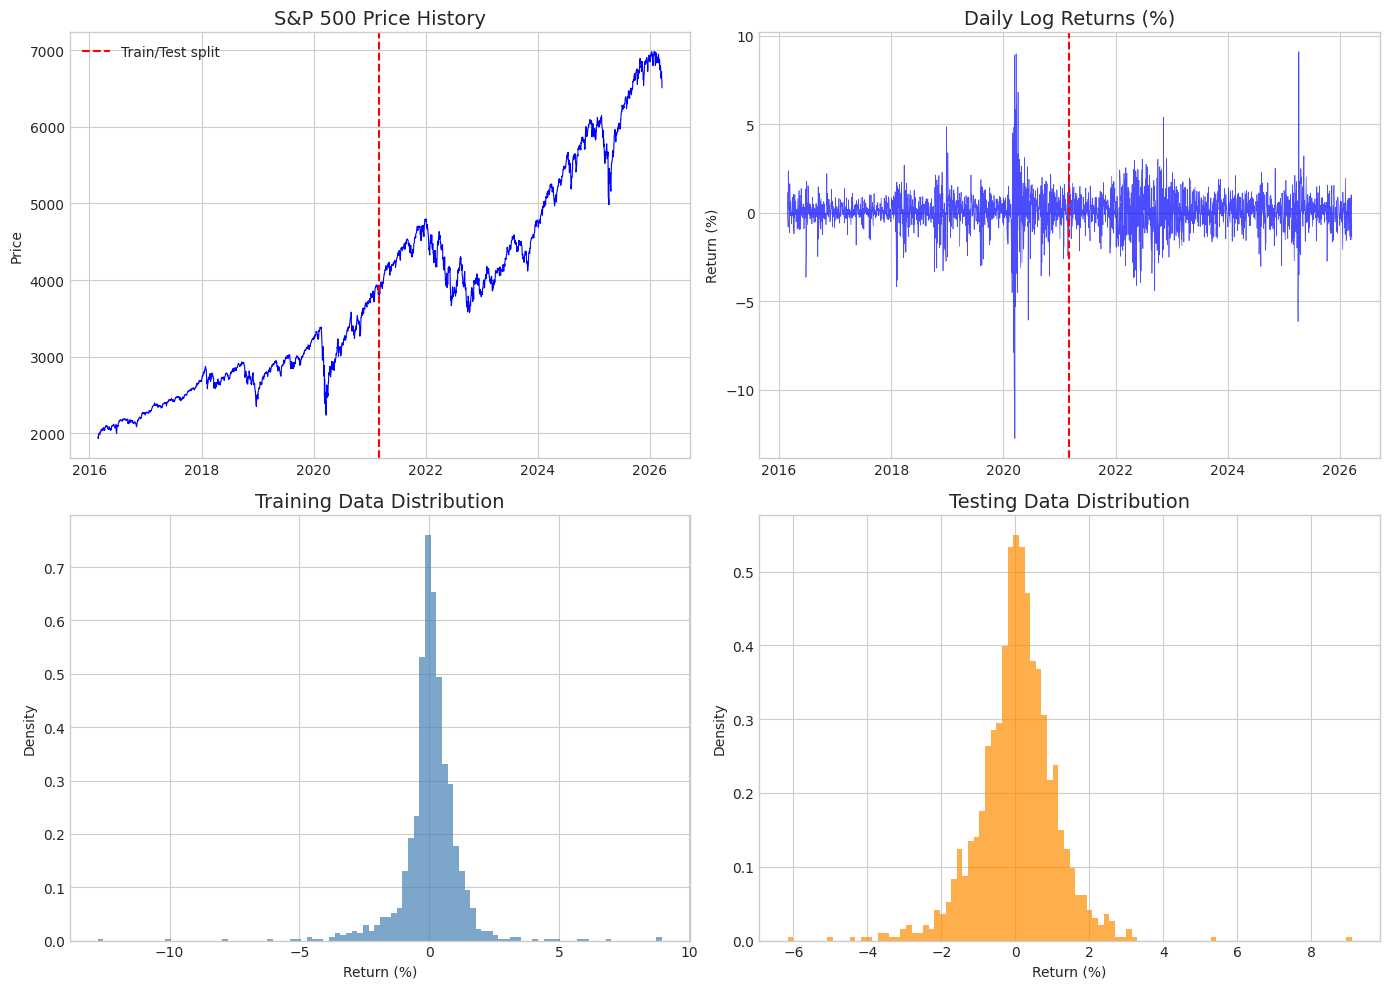

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(sp500.index, sp500['Close'], 'b-', linewidth=0.8)
axes[0, 0].axvline(train_data.index[-1], color='red', linestyle='--', label='Train/Test split')
axes[0, 0].set_title('S&P 500 Price History', fontsize=14)
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

axes[0, 1].plot(sp500.index, sp500['Log_Return']*100, 'b-', linewidth=0.5, alpha=0.7)
axes[0, 1].axvline(train_data.index[-1], color='red', linestyle='--')
axes[0, 1].set_title('Daily Log Returns (%)', fontsize=14)
axes[0, 1].set_ylabel('Return (%)')

axes[1, 0].hist(returns_train*100, bins=100, density=True, alpha=0.7, color='steelblue')
axes[1, 0].set_title('Training Data Distribution', fontsize=14)
axes[1, 0].set_xlabel('Return (%)')
axes[1, 0].set_ylabel('Density')

axes[1, 1].hist(returns_test*100, bins=100, density=True, alpha=0.7, color='darkorange')
axes[1, 1].set_title('Testing Data Distribution', fontsize=14)
axes[1, 1].set_xlabel('Return (%)')
axes[1, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## 2. Fit Distributions to Training Data

In [6]:
X_train = returns_train.reshape(-1, 1)
X_test = returns_test.reshape(-1, 1)

fitted_dists = {}

print("Fitting distributions to training data...\n")

Fitting distributions to training data...



In [7]:
print("1. Fitting Normal distribution...")
mu_norm, std_norm = stats.norm.fit(returns_train)
fitted_dists['Normal'] = stats.norm(loc=mu_norm, scale=std_norm)
print(f"   μ = {mu_norm:.6f}, σ = {std_norm:.6f}")

1. Fitting Normal distribution...
   μ = 0.000544, σ = 0.012082


In [8]:
print("2. Fitting Student-t distribution...")
df_t, loc_t, scale_t = stats.t.fit(returns_train)
fitted_dists['Student-t'] = stats.t(df=df_t, loc=loc_t, scale=scale_t)
print(f"   df = {df_t:.4f}, loc = {loc_t:.6f}, scale = {scale_t:.6f}")

2. Fitting Student-t distribution...
   df = 1.9516, loc = 0.000996, scale = 0.005066


In [ ]:
print("3. Fitting Variance Gamma distribution (EM algorithm)...")
vg_init = VarianceGamma.default_init(X_train)
vg_result = vg_init.fit(X_train, max_iter=100, tol=1e-2, verbose=1, e_step_backend='cpu')
vg = vg_result.model
fitted_dists['Variance Gamma'] = vg

j = vg.joint
print(f"   μ = {float(j.mu[0]):.6f}, γ = {float(j.gamma[0]):.6f}")
print(f"   σ² = {float(vg.cov()[0,0]):.8f}, α = {float(j.alpha):.4f}, β = {float(j.beta):.4f}")

3. Fitting Variance Gamma distribution (EM algorithm)...

  EM Fitting: VarianceGamma
  Loop         : Python loop
  E-step       : cpu
  M-step       : cpu / newton
  Regularize   : none
  Tolerance    : 1.0e-02
  Max iters    : 100


In [ ]:
print("4. Fitting Normal Inverse Gamma distribution (EM algorithm)...")
ninvg_init = NormalInverseGamma.default_init(X_train)
ninvg_result = ninvg_init.fit(X_train, max_iter=100, tol=1e-6, verbose=1, e_step_backend='cpu')
ninvg = ninvg_result.model
fitted_dists['Normal Inv Gamma'] = ninvg

j = ninvg.joint
print(f"   μ = {float(j.mu[0]):.6f}, γ = {float(j.gamma[0]):.6f}")
print(f"   σ² = {float(ninvg.cov()[0,0]):.8f}, α = {float(j.alpha):.4f}, β = {float(j.beta):.4f}")

4. Fitting Normal Inverse Gamma distribution (EM algorithm)...

  EM Fitting: NormalInverseGamma
  Loop         : Python loop
  E-step       : jax
  M-step       : cpu / lbfgs
  Regularize   : none
  Tolerance    : 1.0e-02
  Max iters    : 100
------------------------------------------------------------
  Iter    Log-Lik       ΔLL        |Δparams|   Time
------------------------------------------------------------
     1  nan      ---      nan  1.073s
     2  nan  +nan  nan  0.902s
     3  nan  +nan  nan  0.910s
     4  nan  +nan  nan  0.896s
     5  nan  +nan  nan  0.927s


Exception ignored in: <function _xla_gc_callback at 0x7e1c815a3a60>
Traceback (most recent call last):
  File "/home/bajie/github/normix/.venv/lib/python3.12/site-packages/jax/_src/lib/__init__.py", line 124, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


     6  nan  +nan  nan  1.158s
     7  nan  +nan  nan  0.881s
     8  nan  +nan  nan  0.825s
     9  nan  +nan  nan  0.827s
    10  nan  +nan  nan  0.844s
    11  nan  +nan  nan  1.066s
    12  nan  +nan  nan  0.890s
    13  nan  +nan  nan  0.897s
    14  nan  +nan  nan  0.893s
    15  nan  +nan  nan  0.904s
    16  nan  +nan  nan  1.164s


In [ ]:
print("5. Fitting Normal Inverse Gaussian distribution (EM algorithm)...")
nig_init = NormalInverseGaussian.default_init(X_train)
nig_result = nig_init.fit(X_train, max_iter=100, tol=1e-6, verbose=1, e_step_backend='cpu')
nig = nig_result.model
fitted_dists['Normal Inv Gaussian'] = nig

j = nig.joint
print(f"   μ = {float(j.mu[0]):.6f}, γ = {float(j.gamma[0]):.6f}")
print(f"   σ² = {float(nig.cov()[0,0]):.8f}, μ_ig = {float(j.mu_ig):.6f}, λ = {float(j.lam):.6f}")

In [ ]:
print("6. Fitting Generalized Hyperbolic distribution (EM algorithm)...")
gh_init = GeneralizedHyperbolic.default_init(X_train)
gh_result = gh_init.fit(X_train, max_iter=100, tol=1e-4, verbose=1)
gh = gh_result.model
fitted_dists['Gen. Hyperbolic'] = gh

j = gh.joint
print(f"   μ = {float(j.mu[0]):.6f}, γ = {float(j.gamma[0]):.6f}")
print(f"   σ² = {float(gh.cov()[0,0]):.8f}")
print(f"   p = {float(j.p):.4f}, a = {float(j.a):.4f}, b = {float(j.b):.4f}")

In [ ]:
print("7. Fitting Stable (Lévy) distribution...")
print("   (This may take a while...)")
alpha_s, beta_s, loc_s, scale_s = stats.levy_stable.fit(returns_train)
fitted_dists['Stable'] = stats.levy_stable(alpha=alpha_s, beta=beta_s, loc=loc_s, scale=scale_s)
print(f"   α = {alpha_s:.4f}, β = {beta_s:.4f}, loc = {loc_s:.6f}, scale = {scale_s:.6f}")

print("\nAll distributions fitted!")

## 3. In-Sample Comparison (Training Data)

In [ ]:
def get_pdf_values(dist, x, dist_name):
    """Get PDF values — handles both scipy and normix distributions."""
    if dist_name in ['Normal', 'Student-t', 'Stable']:
        return dist.pdf(x)
    else:
        x_jnp = jnp.asarray(x.reshape(-1, 1), dtype=jnp.float64)
        return np.asarray(jax.vmap(dist.pdf)(x_jnp)).flatten()

def generate_samples(dist, n_samples, dist_name, seed=42):
    """Generate samples from a distribution."""
    if dist_name in ['Normal', 'Student-t', 'Stable']:
        return dist.rvs(size=n_samples, random_state=seed)
    else:
        return dist.rvs(n_samples, seed=seed).flatten()

In [ ]:
x_range = np.linspace(returns_train.min() * 1.2, returns_train.max() * 1.2, 500)

colors = {
    'Normal': 'blue',
    'Student-t': 'red',
    'Variance Gamma': 'green',
    'Normal Inv Gamma': 'purple',
    'Normal Inv Gaussian': 'orange',
    'Gen. Hyperbolic': 'brown',
    'Stable': 'cyan'
}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(returns_train, bins=100, density=True, alpha=0.5, color='gray', label='Data')
for name, dist in fitted_dists.items():
    pdf_vals = get_pdf_values(dist, x_range, name)
    axes[0].plot(x_range, pdf_vals, color=colors[name], linewidth=1.5, label=name)

axes[0].set_xlabel('Log Return', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('In-Sample: PDF Comparison (Linear Scale)', fontsize=14)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(returns_train.min() * 1.1, returns_train.max() * 1.1)

axes[1].hist(returns_train, bins=100, density=True, alpha=0.5, color='gray', label='Data')
for name, dist in fitted_dists.items():
    pdf_vals = get_pdf_values(dist, x_range, name)
    pdf_vals = np.clip(pdf_vals, 1e-10, None)
    axes[1].semilogy(x_range, pdf_vals, color=colors[name], linewidth=1.5, label=name)

axes[1].set_xlabel('Log Return', fontsize=12)
axes[1].set_ylabel('Density (log scale)', fontsize=12)
axes[1].set_title('In-Sample: Tail Comparison (Log Scale)', fontsize=14)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(returns_train.min() * 1.1, returns_train.max() * 1.1)
axes[1].set_ylim(1e-4, None)

plt.tight_layout()
plt.show()

## 4. Out-of-Sample Comparison (Testing Data)

In [ ]:
x_range_test = np.linspace(returns_test.min() * 1.2, returns_test.max() * 1.2, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(returns_test, bins=100, density=True, alpha=0.5, color='gray', label='Test Data')
for name, dist in fitted_dists.items():
    pdf_vals = get_pdf_values(dist, x_range_test, name)
    axes[0].plot(x_range_test, pdf_vals, color=colors[name], linewidth=1.5, label=name)

axes[0].set_xlabel('Log Return', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Out-of-Sample: PDF Comparison (Linear Scale)', fontsize=14)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(returns_test.min() * 1.1, returns_test.max() * 1.1)

axes[1].hist(returns_test, bins=100, density=True, alpha=0.5, color='gray', label='Test Data')
for name, dist in fitted_dists.items():
    pdf_vals = get_pdf_values(dist, x_range_test, name)
    pdf_vals = np.clip(pdf_vals, 1e-10, None)
    axes[1].semilogy(x_range_test, pdf_vals, color=colors[name], linewidth=1.5, label=name)

axes[1].set_xlabel('Log Return', fontsize=12)
axes[1].set_ylabel('Density (log scale)', fontsize=12)
axes[1].set_title('Out-of-Sample: Tail Comparison (Log Scale)', fontsize=14)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(returns_test.min() * 1.1, returns_test.max() * 1.1)
axes[1].set_ylim(1e-4, None)

plt.tight_layout()
plt.show()

## 5. Statistical Tests

### 5.1 Kolmogorov-Smirnov Two-Sample Test

In [ ]:
n_sim = 100000

print("Kolmogorov-Smirnov Two-Sample Test")
print("="*70)
print(f"{'Distribution':<20} {'In-Sample KS':<15} {'p-value':<12} {'Out-Sample KS':<15} {'p-value':<12}")
print("-"*70)

ks_results = {}

for name, dist in fitted_dists.items():
    sim_samples = generate_samples(dist, n_sim, name)
    
    ks_in, pval_in = ks_2samp(returns_train, sim_samples)
    ks_out, pval_out = ks_2samp(returns_test, sim_samples)
    
    ks_results[name] = {
        'ks_in': ks_in, 'pval_in': pval_in,
        'ks_out': ks_out, 'pval_out': pval_out
    }
    
    print(f"{name:<20} {ks_in:<15.4f} {pval_in:<12.4f} {ks_out:<15.4f} {pval_out:<12.4f}")

print("\nNote: Lower KS statistic = better fit. p-value > 0.05 suggests distributions are similar.")

### 5.2 Anderson-Darling Test (Two-Sample)

In [ ]:
print("Anderson-Darling Two-Sample Test")
print("="*70)
print(f"{'Distribution':<20} {'In-Sample AD':<15} {'Out-Sample AD':<15} {'Critical 5%':<15}")
print("-"*70)

ad_results = {}

for name, dist in fitted_dists.items():
    sim_samples = generate_samples(dist, n_sim, name)
    
    ad_in = anderson_ksamp([returns_train, sim_samples])
    ad_out = anderson_ksamp([returns_test, sim_samples])
    
    ad_results[name] = {
        'ad_in': ad_in.statistic, 'ad_out': ad_out.statistic,
        'critical': ad_in.critical_values[2]
    }
    
    print(f"{name:<20} {ad_in.statistic:<15.4f} {ad_out.statistic:<15.4f} {ad_in.critical_values[2]:<15.4f}")

print("\nNote: Lower AD statistic = better fit. Statistic < Critical value suggests good fit.")

## 6. Tail Analysis

### 6.1 Tail Probabilities

In [ ]:
tail_quantiles = [0.01, 0.025, 0.05, 0.95, 0.975, 0.99]

print("Tail Probability Comparison (Out-of-Sample)")
print("="*90)
print(f"{'Quantile':<10}", end="")
print(f"{'Empirical':<12}", end="")
for name in fitted_dists.keys():
    print(f"{name[:10]:<12}", end="")
print()
print("-"*90)

empirical_quantiles = np.quantile(returns_test, tail_quantiles)

for i, q in enumerate(tail_quantiles):
    emp_val = empirical_quantiles[i]
    print(f"{q:<10.3f}", end="")
    print(f"{emp_val:<12.6f}", end="")
    
    for name, dist in fitted_dists.items():
        if name in ['Normal', 'Student-t', 'Stable']:
            fitted_val = dist.ppf(q)
        else:
            samples = generate_samples(dist, 50000, name, seed=456)
            fitted_val = np.quantile(samples, q)
        print(f"{fitted_val:<12.6f}", end="")
    print()

### 6.2 QQ Plots

In [ ]:
def make_qq_plot(ax, data, dist, dist_name, title):
    """Create QQ plot comparing data to fitted distribution."""
    n = len(data)
    sorted_data = np.sort(data)
    theoretical_quantiles = np.linspace(0.001, 0.999, n)
    
    if dist_name in ['Normal', 'Student-t', 'Stable']:
        theoretical_values = dist.ppf(theoretical_quantiles)
    else:
        samples = generate_samples(dist, 50000, dist_name, seed=789)
        theoretical_values = np.quantile(samples, theoretical_quantiles)
    
    ax.scatter(theoretical_values, sorted_data, alpha=0.3, s=5)
    
    lims = [min(theoretical_values.min(), sorted_data.min()),
            max(theoretical_values.max(), sorted_data.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    
    ax.set_xlabel('Theoretical Quantiles', fontsize=10)
    ax.set_ylabel('Sample Quantiles', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(loc='lower right', fontsize=8)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, (name, dist) in enumerate(fitted_dists.items()):
    make_qq_plot(axes[i], returns_test, dist, name, f'QQ Plot: {name}')

axes[-1].axis('off')

plt.suptitle('Out-of-Sample QQ Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Tail Index Estimation (Hill Estimator)

In [ ]:
def hill_estimator(data, k):
    """Hill estimator for tail index using top k order statistics."""
    sorted_data = np.sort(np.abs(data))[::-1]
    if k >= len(data) or k < 1:
        return np.nan
    log_ratios = np.log(sorted_data[:k]) - np.log(sorted_data[k])
    return k / np.sum(log_ratios)

k_values = np.arange(10, 200, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left_tail_train = -returns_train[returns_train < 0]
left_tail_test = -returns_test[returns_test < 0]

hill_left_train = [hill_estimator(left_tail_train, k) for k in k_values]
hill_left_test = [hill_estimator(left_tail_test, k) for k in k_values]

axes[0].plot(k_values, hill_left_train, 'b-', linewidth=2, label='Training')
axes[0].plot(k_values, hill_left_test, 'r--', linewidth=2, label='Testing')
axes[0].axhline(y=3, color='gray', linestyle=':', label='α=3 (finite variance)')
axes[0].axhline(y=2, color='gray', linestyle='-.', label='α=2 (finite mean)')
axes[0].set_xlabel('Number of order statistics (k)', fontsize=12)
axes[0].set_ylabel('Tail index α', fontsize=12)
axes[0].set_title('Left Tail (Losses) - Hill Estimator', fontsize=14)
axes[0].legend()
axes[0].set_ylim(0, 6)

right_tail_train = returns_train[returns_train > 0]
right_tail_test = returns_test[returns_test > 0]

hill_right_train = [hill_estimator(right_tail_train, k) for k in k_values]
hill_right_test = [hill_estimator(right_tail_test, k) for k in k_values]

axes[1].plot(k_values, hill_right_train, 'b-', linewidth=2, label='Training')
axes[1].plot(k_values, hill_right_test, 'r--', linewidth=2, label='Testing')
axes[1].axhline(y=3, color='gray', linestyle=':', label='α=3')
axes[1].axhline(y=2, color='gray', linestyle='-.', label='α=2')
axes[1].set_xlabel('Number of order statistics (k)', fontsize=12)
axes[1].set_ylabel('Tail index α', fontsize=12)
axes[1].set_title('Right Tail (Gains) - Hill Estimator', fontsize=14)
axes[1].legend()
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.show()

k_stable = 50
print(f"\nHill Tail Index Estimates (k={k_stable}):")
print(f"  Left tail (losses):  Train={hill_estimator(left_tail_train, k_stable):.3f}, Test={hill_estimator(left_tail_test, k_stable):.3f}")
print(f"  Right tail (gains):  Train={hill_estimator(right_tail_train, k_stable):.3f}, Test={hill_estimator(right_tail_test, k_stable):.3f}")

## 7. Value at Risk (VaR) Backtesting

In [ ]:
def compute_var(dist, alpha, dist_name):
    """Compute Value at Risk at level alpha."""
    if dist_name in ['Normal', 'Student-t', 'Stable']:
        return dist.ppf(alpha)
    else:
        samples = generate_samples(dist, 100000, dist_name, seed=999)
        return np.quantile(samples, alpha)

var_levels = [0.01, 0.025, 0.05]

print("Value at Risk Backtesting (Out-of-Sample)")
print("="*80)

for alpha in var_levels:
    print(f"\nVaR at {alpha*100:.1f}% level (Expected exceedances: {alpha*100:.1f}%)")
    print("-"*60)
    print(f"{'Distribution':<20} {'VaR':<15} {'Exceedances':<15} {'Rate (%)':<12}")
    print("-"*60)
    
    for name, dist in fitted_dists.items():
        var = compute_var(dist, alpha, name)
        exceedances = np.sum(returns_test < var)
        rate = exceedances / len(returns_test) * 100
        
        print(f"{name:<20} {var:<15.6f} {exceedances:<15d} {rate:<12.2f}")